# 02. Modeling

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

sns.set_theme(style='whitegrid')
DATA_PATH = Path('../data/processed/reviews_dataset.csv')
df = pd.read_csv(DATA_PATH)
class_order = ['newbie', 'casual', 'engaged', 'veteran']

In [2]:
target = 'experience_class'
text_column = 'review'
base_metadata_columns = [
    'game', 
    'game_group', 
    'voted_up', 
    'votes_up', 
    'votes_funny', 
    'weighted_vote_score',
    'comment_count', 
    'steam_purchase', 
    'received_for_free',
    'written_during_early_access', 
    'author_num_games_owned',
    'author_num_reviews',
]

##### Функции для выбора среза данных и построения моделей

In [3]:
def subset_by_group(data, group):
    if group == 'all':
        return data.copy()
    return data[data['game_group'] == group].copy()


def text_selector(frame):
    return frame[text_column].fillna('')


def build_text_logreg():
    return Pipeline([
        ('text', FunctionTransformer(text_selector, validate=False)),
        ('tfidf', TfidfVectorizer(min_df=3, max_df=0.85, ngram_range=(1, 2), max_features=50000)),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000)),
    ])


def build_text_metadata_logreg(metadata_columns):
    categorical_features = [
        column for column in [
            'game', 'game_group', 'voted_up', 'steam_purchase',
            'received_for_free', 'written_during_early_access',
        ]
        if column in metadata_columns
    ]
    numeric_features = [column for column in metadata_columns if column not in categorical_features]

    preprocess = ColumnTransformer([
        ('text', TfidfVectorizer(min_df=3, max_df=0.85, ngram_range=(1, 2), max_features=50000), text_column),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler(with_mean=False)),
        ]), numeric_features),
        ('cat', Pipeline([
            ('to_object', FunctionTransformer(lambda values: values.astype(object), validate=False)),
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore')),
        ]), categorical_features),
    ], remainder='drop')

    return Pipeline([
        ('preprocess', preprocess),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42)),
    ])

##### Функция обучения и оценки моделей

In [4]:
def evaluate_group(data, group_name):
    group_df = subset_by_group(data, group_name)
    metadata_columns = [column for column in base_metadata_columns if column in group_df.columns]
    X = group_df[[text_column] + metadata_columns].copy()
    y = group_df[target].astype(str)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    models = {
        'dummy_most_frequent': DummyClassifier(strategy='most_frequent'),
        'text_only': build_text_logreg(),
        'text_metadata': build_text_metadata_logreg(metadata_columns),
    }

    rows = []
    predictions_by_model = {}
    fitted_models = {}
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)
        rows.append({
            'game_group': group_name,
            'model': model_name,
            'accuracy': accuracy_score(y_test, predictions),
            'macro_f1': f1_score(y_test, predictions, average='macro'),
        })
        predictions_by_model[model_name] = predictions
        fitted_models[model_name] = model

    results = pd.DataFrame(rows).sort_values('macro_f1', ascending=False)
    best_name = results.iloc[0]['model']
    return {
        'group_name': group_name,
        'data': group_df,
        'results': results,
        'best_name': best_name,
        'best_model': fitted_models[best_name],
        'best_predictions': predictions_by_model[best_name],
        'X_test': X_test,
        'y_test': y_test,
    }

##### Обучение моделей и сводная таблица метрик

In [5]:
group_runs = {group: evaluate_group(df, group) for group in ['all', 'offline', 'competitive']}
all_results = pd.concat([run['results'] for run in group_runs.values()], ignore_index=True)
all_results.sort_values(['game_group', 'macro_f1'], ascending=[True, False])

,game_group,model,accuracy,macro_f1
0,all,text_metadata,0.512718,0.510442
1,all,text_only,0.447791,0.438773
2,all,dummy_most_frequent,0.371486,0.135432
6,competitive,text_metadata,0.420975,0.416143
7,competitive,text_only,0.388479,0.382795
8,competitive,dummy_most_frequent,0.311669,0.118806
3,offline,text_metadata,0.545232,0.485411
4,offline,text_only,0.481663,0.424608
5,offline,dummy_most_frequent,0.480440,0.162263


##### Сравнение `macro_f1` моделей по группам

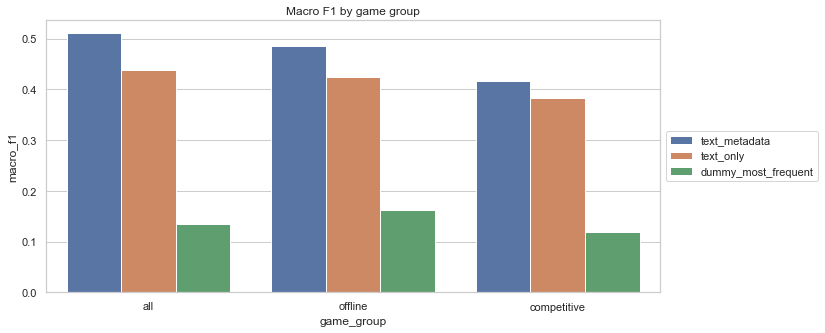

In [6]:
plt.figure(figsize=(11, 5))
sns.barplot(data=all_results, x='game_group', y='macro_f1', hue='model')
plt.title('Macro F1 by game group')
plt.xlabel('game_group')
plt.ylabel('macro_f1')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

##### Confusion matrix для лучшей модели в каждом срезе

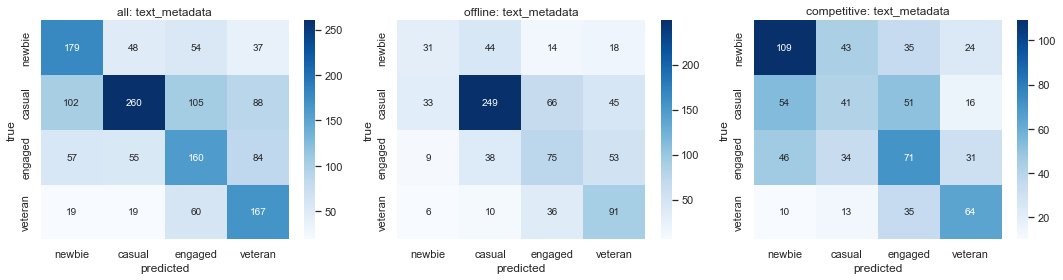

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, group_name in zip(axes, ['all', 'offline', 'competitive']):
    run = group_runs[group_name]
    matrix = confusion_matrix(run['y_test'], run['best_predictions'], labels=class_order)
    sns.heatmap(matrix, annot=True, fmt='d', xticklabels=class_order, yticklabels=class_order, cmap='Blues', ax=ax)
    ax.set_title(f"{group_name}: {run['best_name']}")
    ax.set_xlabel('predicted')
    ax.set_ylabel('true')
plt.tight_layout()
plt.show()

##### Classification report для каждого среза

In [8]:
for group_name in ['all', 'offline', 'competitive']:
    run = group_runs[group_name]
    print(f"\n{group_name}: {run['best_name']}")
    print(classification_report(run['y_test'], run['best_predictions'], labels=class_order, zero_division=0))


all: text_metadata
              precision    recall  f1-score   support

      newbie       0.50      0.56      0.53       318
      casual       0.68      0.47      0.55       555
     engaged       0.42      0.45      0.44       356
     veteran       0.44      0.63      0.52       265

    accuracy                           0.51      1494
   macro avg       0.51      0.53      0.51      1494
weighted avg       0.54      0.51      0.52      1494


offline: text_metadata
              precision    recall  f1-score   support

      newbie       0.39      0.29      0.33       107
      casual       0.73      0.63      0.68       393
     engaged       0.39      0.43      0.41       175
     veteran       0.44      0.64      0.52       143

    accuracy                           0.55       818
   macro avg       0.49      0.50      0.49       818
weighted avg       0.56      0.55      0.55       818


competitive: text_metadata
              precision    recall  f1-score   support

   

##### Примеры ошибок модели

In [9]:
error_tables = []
for group_name in ['all', 'offline', 'competitive']:
    run = group_runs[group_name]
    errors = run['X_test'].copy()
    errors['game_group_view'] = group_name
    errors['true_class'] = run['y_test'].values
    errors['predicted_class'] = run['best_predictions']
    errors = errors[errors['true_class'] != errors['predicted_class']]
    error_tables.append(errors[['game_group_view', 'game', 'true_class', 'predicted_class', 'review']].head(3))

pd.concat(error_tables, ignore_index=True)

,game_group_view,game,true_class,predicted_class,review
0,all,Apex Legends,veteran,engaged,"Dollar Store Servers, Hackers Rampant despite ..."
1,all,Red Dead Redemption 2,casual,veteran,Amazing game amazing graphics. Only thing is i...
2,all,Black Myth: Wukong,newbie,engaged,"souls like noob here, never touched a souls , ..."
3,offline,Horizon Zero Dawn Complete Edition,veteran,engaged,I got stressed a little completing the gold ch...
4,offline,Black Myth: Wukong,casual,engaged,"Wukong was absolutely amazing — fun, challengi..."
5,offline,Black Myth: Wukong,casual,newbie,"Flat, unsatisfying combat that is mostly carri..."
6,competitive,War Thunder,casual,engaged,The Mikoyan-Gurevich MiG-15 was a Soviet jet f...
7,competitive,Counter-Strike 2,newbie,engaged,"Guys, do a favor to yourself and never play pr..."
8,competitive,War Thunder,engaged,casual,I highly recommend progressing through this ga...


##### Ключевые слова классов

In [10]:
text_only_terms = []
for group_name in ['all', 'offline', 'competitive']:
    group_df = subset_by_group(df, group_name)
    metadata_columns = [column for column in base_metadata_columns if column in group_df.columns]
    X = group_df[[text_column] + metadata_columns].copy()
    y = group_df[target].astype(str)
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    model = build_text_logreg()
    model.fit(X_train, y_train)
    feature_names = np.array(model.named_steps['tfidf'].get_feature_names_out())
    classifier = model.named_steps['clf']
    for class_index, class_name in enumerate(classifier.classes_):
        top_indices = np.argsort(classifier.coef_[class_index])[-12:][::-1]
        text_only_terms.append({
            'game_group': group_name,
            'class': class_name,
            'top_terms': ', '.join(feature_names[top_indices]),
        })

pd.DataFrame(text_only_terms)

,game_group,class,top_terms
0,all,casual,"bioshock, story, joel, ellie, but, the last, l..."
1,all,engaged,"chapter, grind, gaijin, never, machines, updat..."
2,all,newbie,"steam, ea, titanfall, fun, got, work, so far, ..."
3,all,veteran,"dota, witcher, the witcher, toxic, arthur, que..."
4,offline,casual,"bioshock, joel, ellie, part, of us, plot, game..."
5,offline,engaged,"wukong, 100, chapter, great, boss, machines, s..."
6,offline,newbie,"so far, account, far, just, bioshock, steam, b..."
7,offline,veteran,"witcher, the witcher, arthur, world, quests, p..."
8,competitive,casual,"still, bots, anti, you play, are cheaters, 10,..."
9,competitive,engaged,"the, grind, never, vehicle, что, done, broken,..."
